# Fake vs Real News — Linguistic Pattern Analysis
### What writing patterns separate misinformation from credible journalism?

**Research Question:**
Can we identify consistent linguistic differences between fake and real news articles
— in writing style, word choice, topic distribution, and text structure?

**Dataset:**
- `Fake.csv` — 23,481 fake news articles
- `True.csv` — 21,417 real news articles
- Source: Kaggle (Clément Bisaillon) — political news, 2015–2018

**Tools:** Python · pandas · numpy · matplotlib · seaborn · nltk · collections

**Author:** Shamizer Hussain | github.com/shamizer-h

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import string
import re
import nltk
import os
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('vader_lexicon', quiet=True)
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

os.makedirs('charts', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize']   = 11

C_FAKE = '#d62728'
C_REAL = '#2ca02c'
C_MID  = '#1f77b4'

print('libraries loaded.')

libraries loaded.


## 1. Load & Prepare Data

In [2]:
fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')

fake['label'] = 'FAKE'
true['label'] = 'REAL'

df = pd.concat([fake, true], ignore_index=True)
df = df.dropna(subset=['title', 'text'])
df = df.reset_index(drop=True)

df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))
df['text_word_count']  = df['text'].apply(lambda x: len(str(x).split()))
df['title_char_count'] = df['title'].apply(lambda x: len(str(x)))
df['exclamation_count']= df['title'].apply(lambda x: str(x).count('!'))
df['caps_word_count']  = df['title'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1)
)

print(f'Total articles : {len(df):,}')
print(f'Fake           : {len(df[df.label=="FAKE"]):,}')
print(f'Real           : {len(df[df.label=="REAL"]):,}')
print()
print(df[['label','title_word_count','text_word_count','exclamation_count']].groupby('label').mean().round(2))

Total articles : 44,898
Fake           : 23,481
Real           : 21,417

       title_word_count  text_word_count  exclamation_count
label                                                      
FAKE              14.73           423.20               0.15
REAL               9.95           385.64               0.00


## 2. Text Preprocessing Pipeline

Before any linguistic analysis, headlines are cleaned through a
standardised preprocessing pipeline: lowercasing, punctuation removal,
stopword filtering, and short-token removal. The cleaned text is stored
as a new column and reused in all subsequent analyses.

In [3]:
stop_words = set(stopwords.words('english'))
stop_words.update(['said', 'would', 'one', 'also', 'u', 's', 'us'])

def preprocess(text):
    """Lowercase → remove punctuation → tokenise → filter stopwords & short tokens."""
    text  = str(text).lower()
    text  = re.sub(r'[^a-z\s]', '', text)          # remove punctuation & digits
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df['clean_title_tokens'] = df['title'].apply(preprocess)
df['clean_title']        = df['clean_title_tokens'].apply(lambda t: ' '.join(t))

# quick sanity check
print('Original  :', df['title'].iloc[0])
print('Cleaned   :', df['clean_title'].iloc[0])
print()
print(f'Preprocessing complete — clean_title column added ({len(df):,} rows)')

Original  :  Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing
Cleaned   : donald trump sends embarrassing new years eve message disturbing

Preprocessing complete — clean_title column added (44,898 rows)


## 3. Dataset Overview & Article Length Distribution

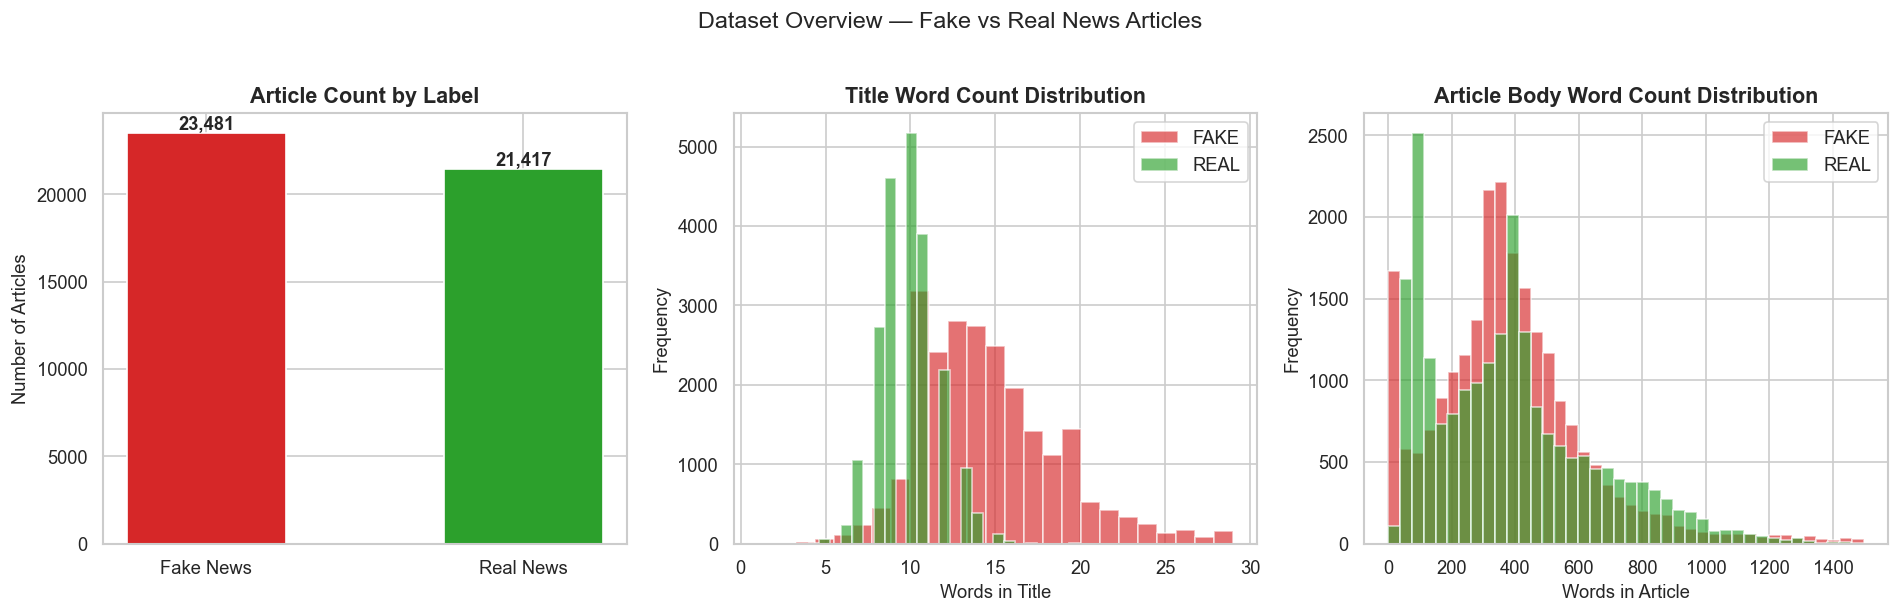

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(['Fake News', 'Real News'],
            [len(df[df.label=='FAKE']), len(df[df.label=='REAL'])],
            color=[C_FAKE, C_REAL], width=0.5, edgecolor='white')
axes[0].set_title('Article Count by Label')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate([len(df[df.label=='FAKE']), len(df[df.label=='REAL'])]):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

for label, color in [('FAKE', C_FAKE), ('REAL', C_REAL)]:
    subset = df[df.label == label]['title_word_count']
    subset = subset[subset < 30]
    axes[1].hist(subset, bins=25, alpha=0.65, color=color, label=label, edgecolor='white')
axes[1].set_title('Title Word Count Distribution')
axes[1].set_xlabel('Words in Title')
axes[1].set_ylabel('Frequency')
axes[1].legend()

for label, color in [('FAKE', C_FAKE), ('REAL', C_REAL)]:
    subset = df[df.label == label]['text_word_count']
    subset = subset[subset < 1500]
    axes[2].hist(subset, bins=40, alpha=0.65, color=color, label=label, edgecolor='white')
axes[2].set_title('Article Body Word Count Distribution')
axes[2].set_xlabel('Words in Article')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Dataset Overview — Fake vs Real News Articles', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/chart1_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sensationalism Markers in Headlines

Fake news tends to use more emotionally charged language — excessive punctuation,
ALL CAPS words, and longer dramatic headlines.

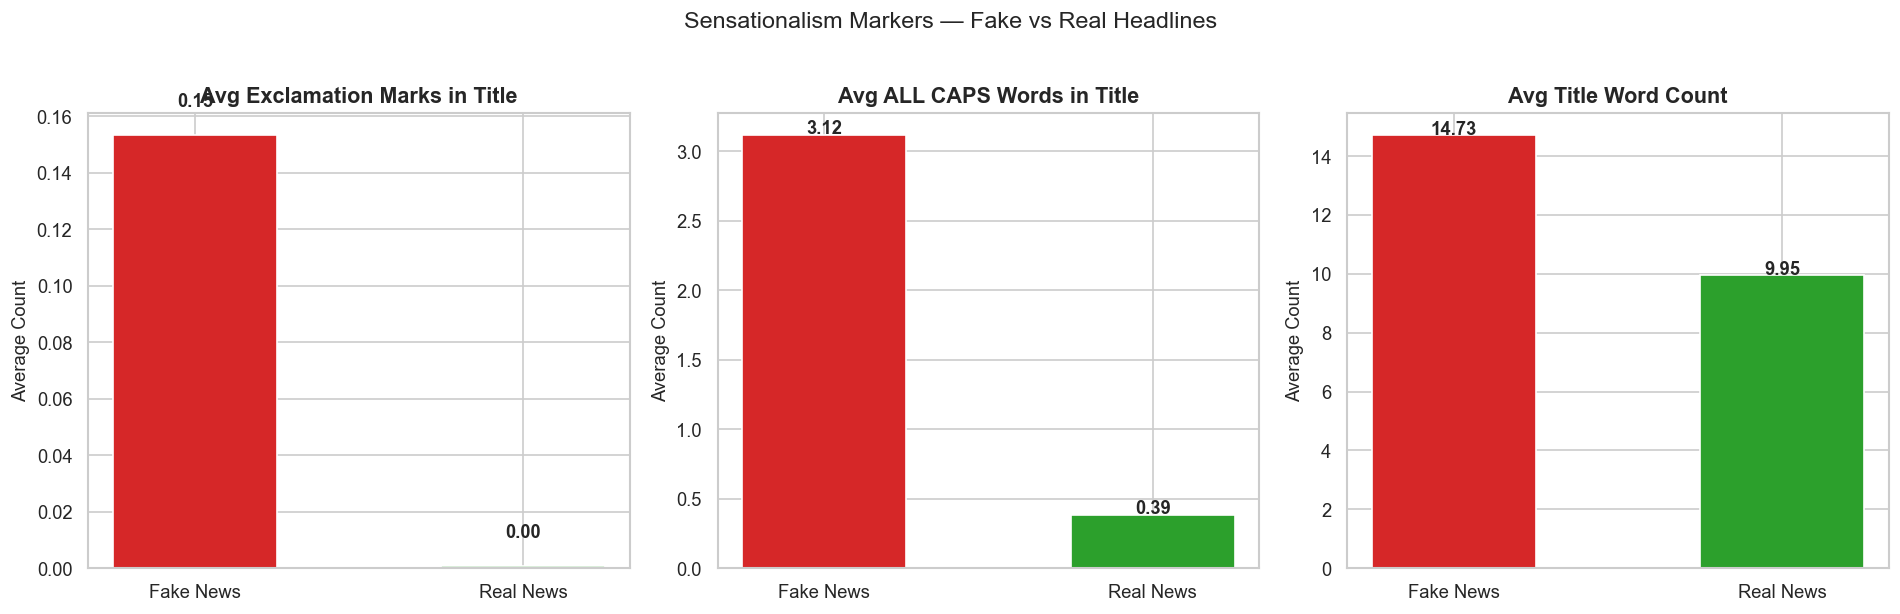

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('exclamation_count', 'Avg Exclamation Marks in Title'),
    ('caps_word_count',   'Avg ALL CAPS Words in Title'),
    ('title_word_count',  'Avg Title Word Count'),
]

for ax, (col, ylabel) in zip(axes, metrics):
    vals = df.groupby('label')[col].mean()
    bars = ax.bar(['Fake News', 'Real News'],
                  [vals['FAKE'], vals['REAL']],
                  color=[C_FAKE, C_REAL], width=0.5, edgecolor='white')
    ax.set_title(ylabel)
    ax.set_ylabel('Average Count')
    for bar, val in zip(bars, [vals['FAKE'], vals['REAL']]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Sensationalism Markers — Fake vs Real Headlines', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/chart2_sensationalism.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Topic / Subject Distribution

What topics do fake vs real news articles tend to cover?

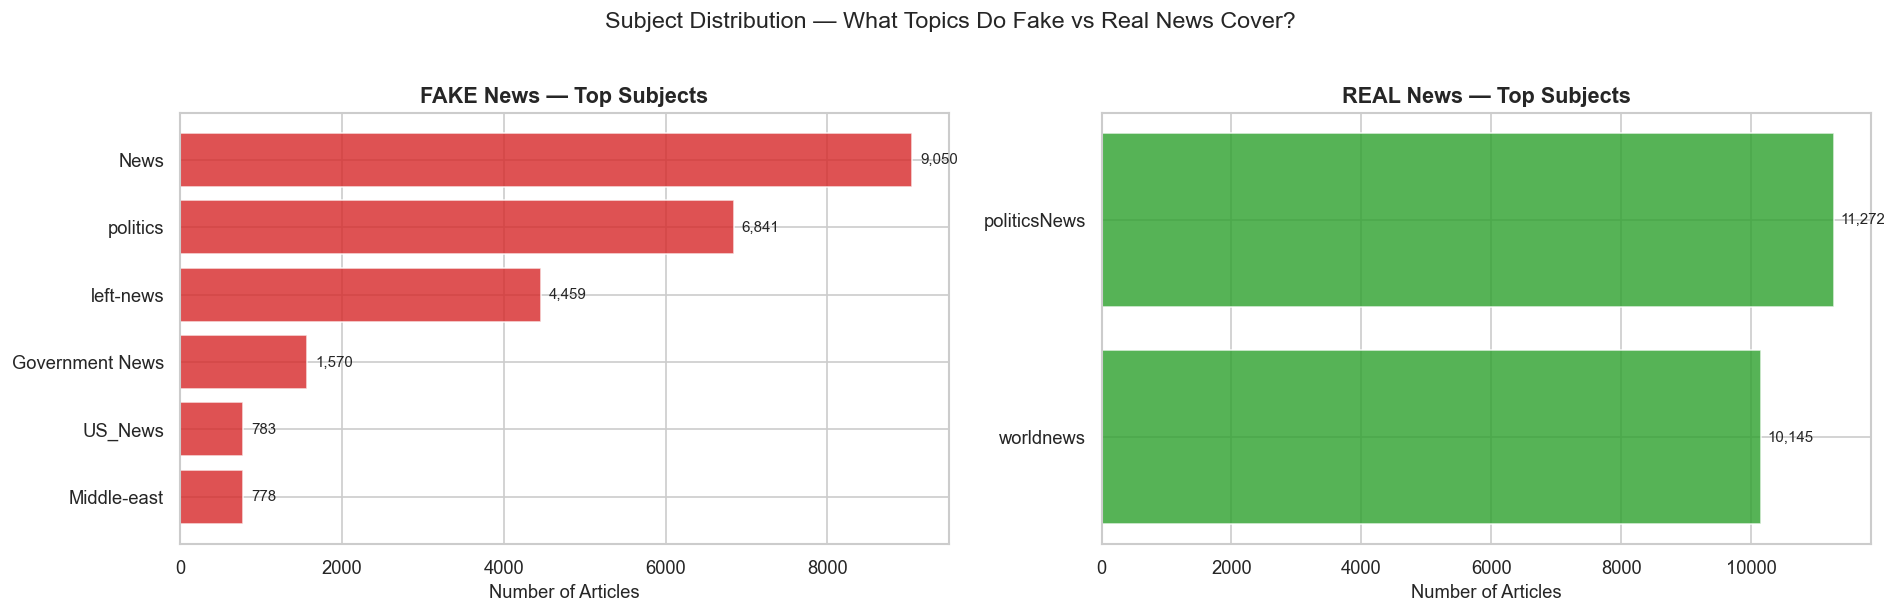

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label, color in [(axes[0], 'FAKE', C_FAKE), (axes[1], 'REAL', C_REAL)]:
    subject_counts = df[df.label == label]['subject'].value_counts().head(8)
    bars = ax.barh(subject_counts.index[::-1], subject_counts.values[::-1],
                   color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{label} News — Top Subjects')
    ax.set_xlabel('Number of Articles')
    for bar, val in zip(bars, subject_counts.values[::-1]):
        ax.text(val + 100, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

plt.suptitle('Subject Distribution — What Topics Do Fake vs Real News Cover?', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/chart3_subject_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Most Frequent Words — Fake vs Real

After removing stopwords, what words appear most in fake vs real headlines?

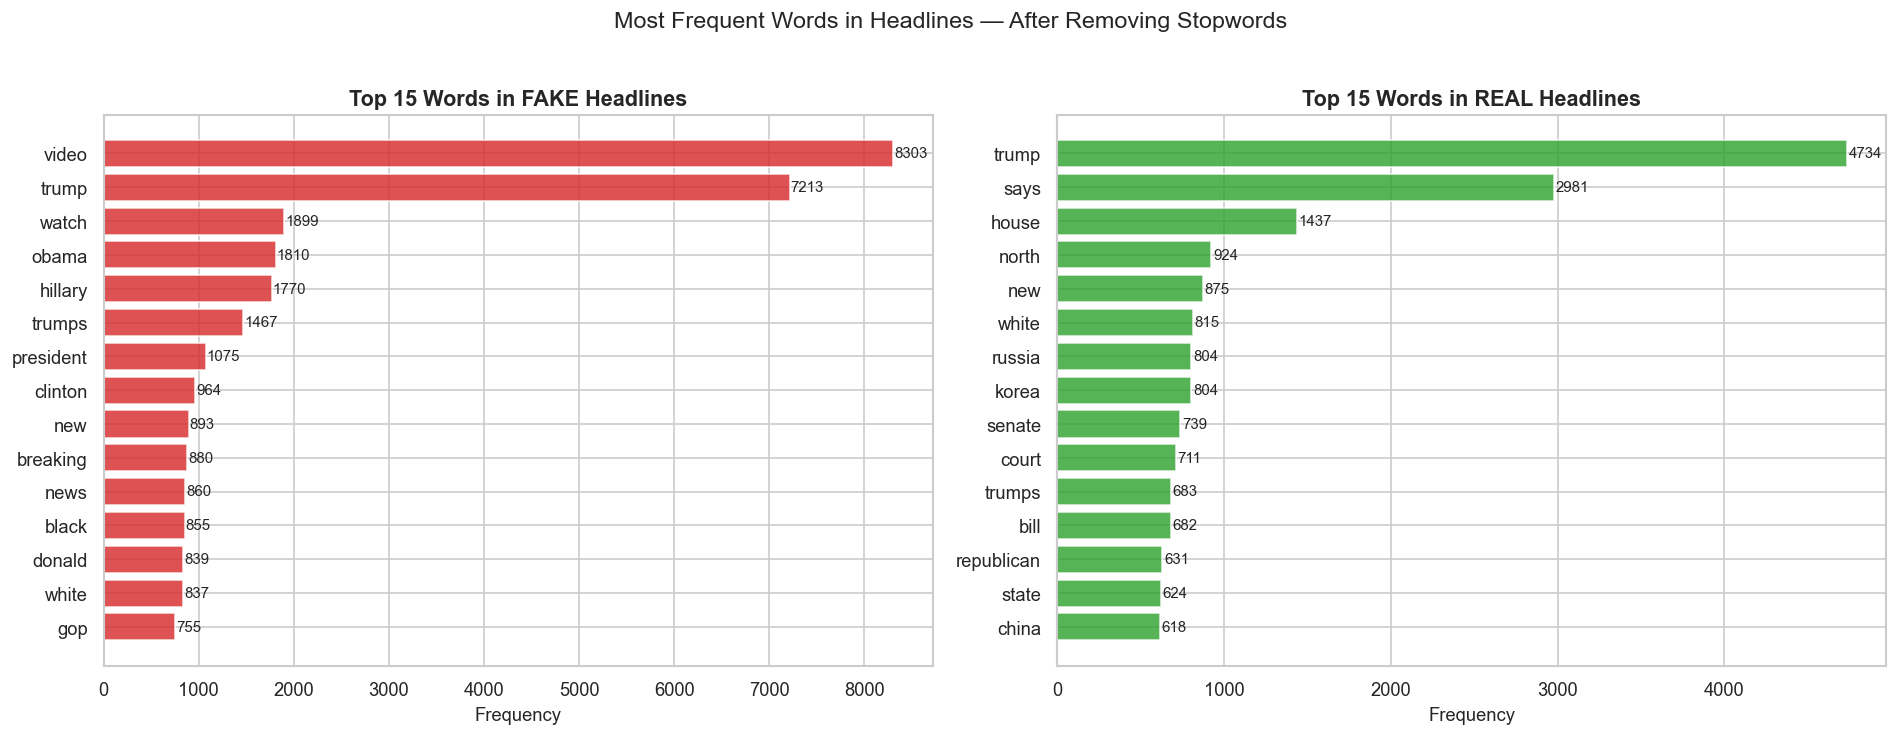

In [7]:
def get_top_words(token_series, n=15):
    all_words = [word for tokens in token_series for word in tokens]
    return Counter(all_words).most_common(n)

fake_words = get_top_words(df[df.label=='FAKE']['clean_title_tokens'])
real_words = get_top_words(df[df.label=='REAL']['clean_title_tokens'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, words, label, color in [
    (axes[0], fake_words, 'FAKE', C_FAKE),
    (axes[1], real_words, 'REAL', C_REAL)
]:
    words_list  = [w[0] for w in words][::-1]
    counts_list = [w[1] for w in words][::-1]
    ax.barh(words_list, counts_list, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Top 15 Words in {label} Headlines')
    ax.set_xlabel('Frequency')
    for i, v in enumerate(counts_list):
        ax.text(v + 10, i, str(v), va='center', fontsize=9)

plt.suptitle('Most Frequent Words in Headlines — After Removing Stopwords', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/chart4_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Vocabulary Distribution — Lexical Diversity

Type-Token Ratio (TTR) measures lexical richness: unique words divided by total words.
A higher TTR means more varied vocabulary. We compare TTR across both classes
and across all 6 content categories to see where vocabulary diversity diverges.

Lexical Diversity (Type-Token Ratio)
  FAKE headlines TTR : 0.0766
  REAL headlines TTR : 0.0875
  Real news uses 14.2% richer vocabulary than fake news.



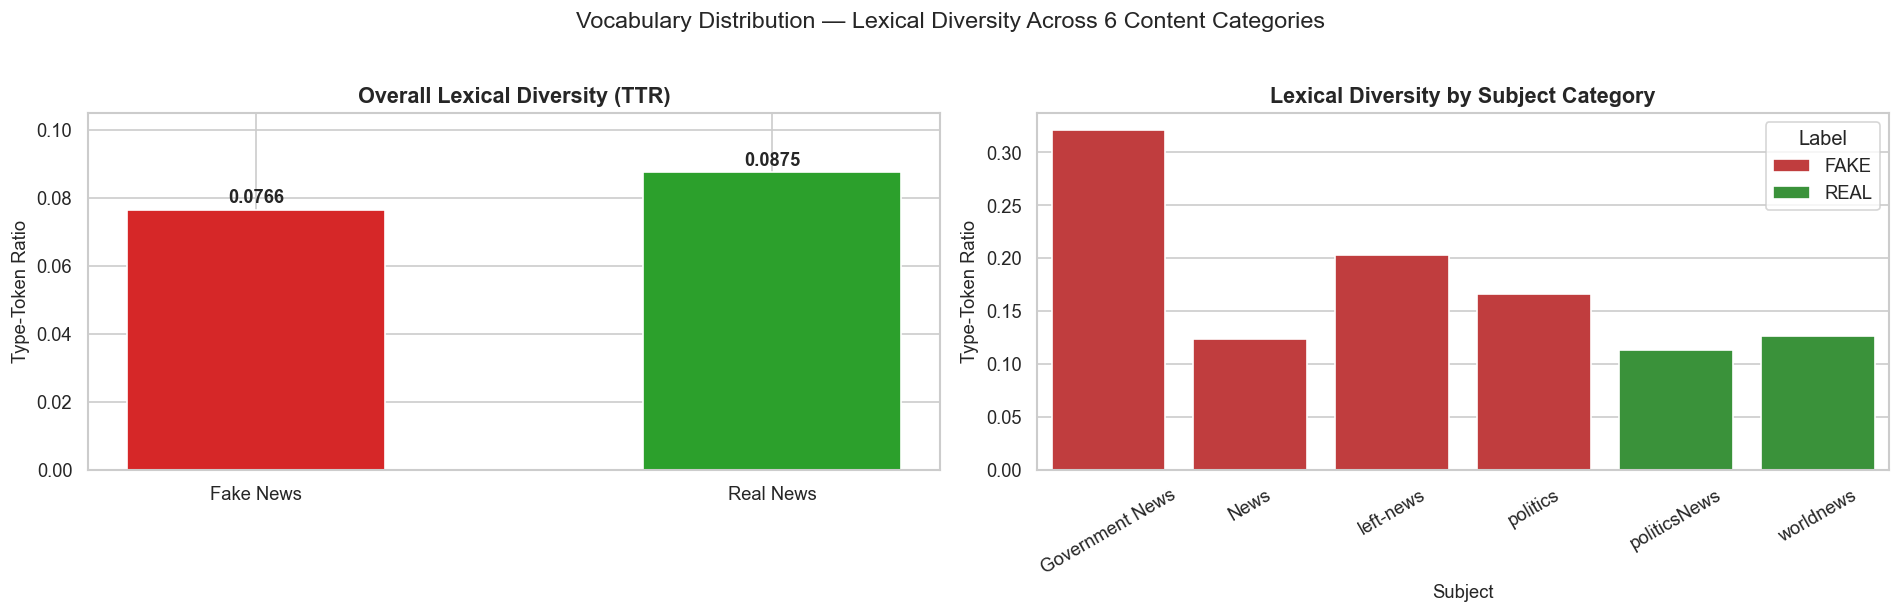

In [8]:
def type_token_ratio(token_series):
    all_tokens  = [t for tokens in token_series for t in tokens]
    if len(all_tokens) == 0:
        return 0
    return round(len(set(all_tokens)) / len(all_tokens), 4)

# --- overall TTR by label ---
ttr_fake = type_token_ratio(df[df.label=='FAKE']['clean_title_tokens'])
ttr_real = type_token_ratio(df[df.label=='REAL']['clean_title_tokens'])

print('Lexical Diversity (Type-Token Ratio)')
print(f'  FAKE headlines TTR : {ttr_fake}')
print(f'  REAL headlines TTR : {ttr_real}')
print(f'  Real news uses {round((ttr_real - ttr_fake) / ttr_fake * 100, 1)}% richer vocabulary than fake news.')
print()

# --- TTR by subject (all 6 categories) ---
ttr_by_subject = (
    df.groupby(['subject', 'label'])['clean_title_tokens']
      .apply(type_token_ratio)
      .reset_index()
)
ttr_by_subject.columns = ['subject', 'label', 'ttr']
top_subjects = df['subject'].value_counts().head(6).index
ttr_by_subject = ttr_by_subject[ttr_by_subject['subject'].isin(top_subjects)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# bar chart — overall TTR
axes[0].bar(['Fake News', 'Real News'], [ttr_fake, ttr_real],
            color=[C_FAKE, C_REAL], width=0.5, edgecolor='white')
axes[0].set_title('Overall Lexical Diversity (TTR)')
axes[0].set_ylabel('Type-Token Ratio')
axes[0].set_ylim(0, max(ttr_fake, ttr_real) * 1.2)
for i, v in enumerate([ttr_fake, ttr_real]):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# grouped bar — TTR by subject
sns.barplot(data=ttr_by_subject, x='subject', y='ttr', hue='label',
            palette={'FAKE': C_FAKE, 'REAL': C_REAL}, ax=axes[1])
axes[1].set_title('Lexical Diversity by Subject Category')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Type-Token Ratio')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Label')

plt.suptitle('Vocabulary Distribution — Lexical Diversity Across 6 Content Categories',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/chart6_lexical_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Article Length — Fake vs Real

Do fake news articles tend to be shorter or longer than real ones?

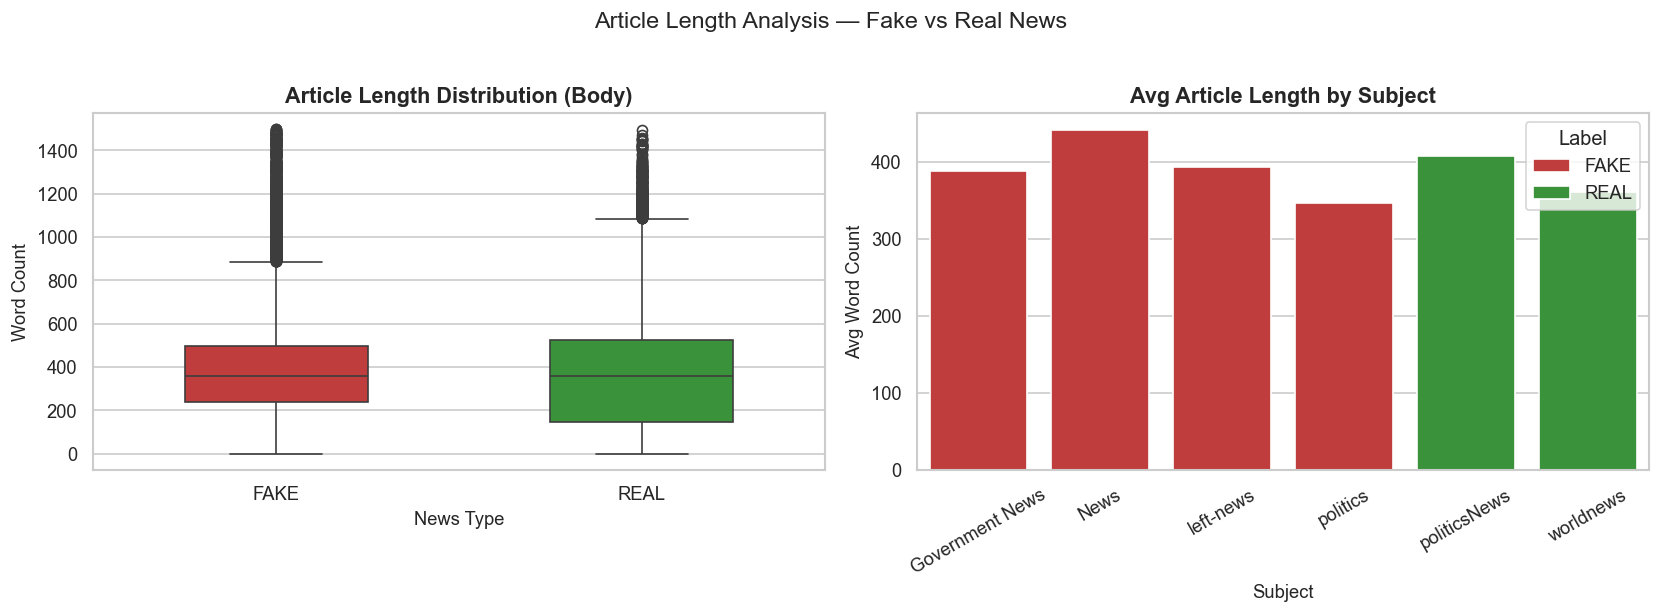

All charts saved to charts/ folder.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = df[df['text_word_count'] < 1500].copy()

sns.boxplot(data=plot_df, x='label', y='text_word_count',
            palette={'FAKE': C_FAKE, 'REAL': C_REAL},
            width=0.5, ax=axes[0])
axes[0].set_title('Article Length Distribution (Body)')
axes[0].set_xlabel('News Type')
axes[0].set_ylabel('Word Count')

mean_len = df.groupby(['subject', 'label'])['text_word_count'].mean().reset_index()
mean_len = mean_len[mean_len['text_word_count'] < 1500]
top_subjects = df['subject'].value_counts().head(6).index
mean_len = mean_len[mean_len['subject'].isin(top_subjects)]

sns.barplot(data=mean_len, x='subject', y='text_word_count', hue='label',
            palette={'FAKE': C_FAKE, 'REAL': C_REAL}, ax=axes[1])
axes[1].set_title('Avg Article Length by Subject')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Avg Word Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Label')

plt.suptitle('Article Length Analysis — Fake vs Real News', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/chart5_article_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('All charts saved to charts/ folder.')

## 9. NLP — Sentiment Analysis (VADER)

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based
sentiment analyser built specifically for short, informal text — making it
well-suited for news headlines. It scores each headline on a compound scale
from -1 (most negative) to +1 (most positive).

Hypothesis: fake news headlines skew more negative or extreme to drive emotional engagement.

Average VADER Sentiment Scores by Label
       sentiment_compound  sentiment_pos  sentiment_neg  sentiment_neu
label                                                                 
FAKE              -0.1607         0.0850         0.1565         0.7585
REAL              -0.0674         0.0795         0.1182         0.8023



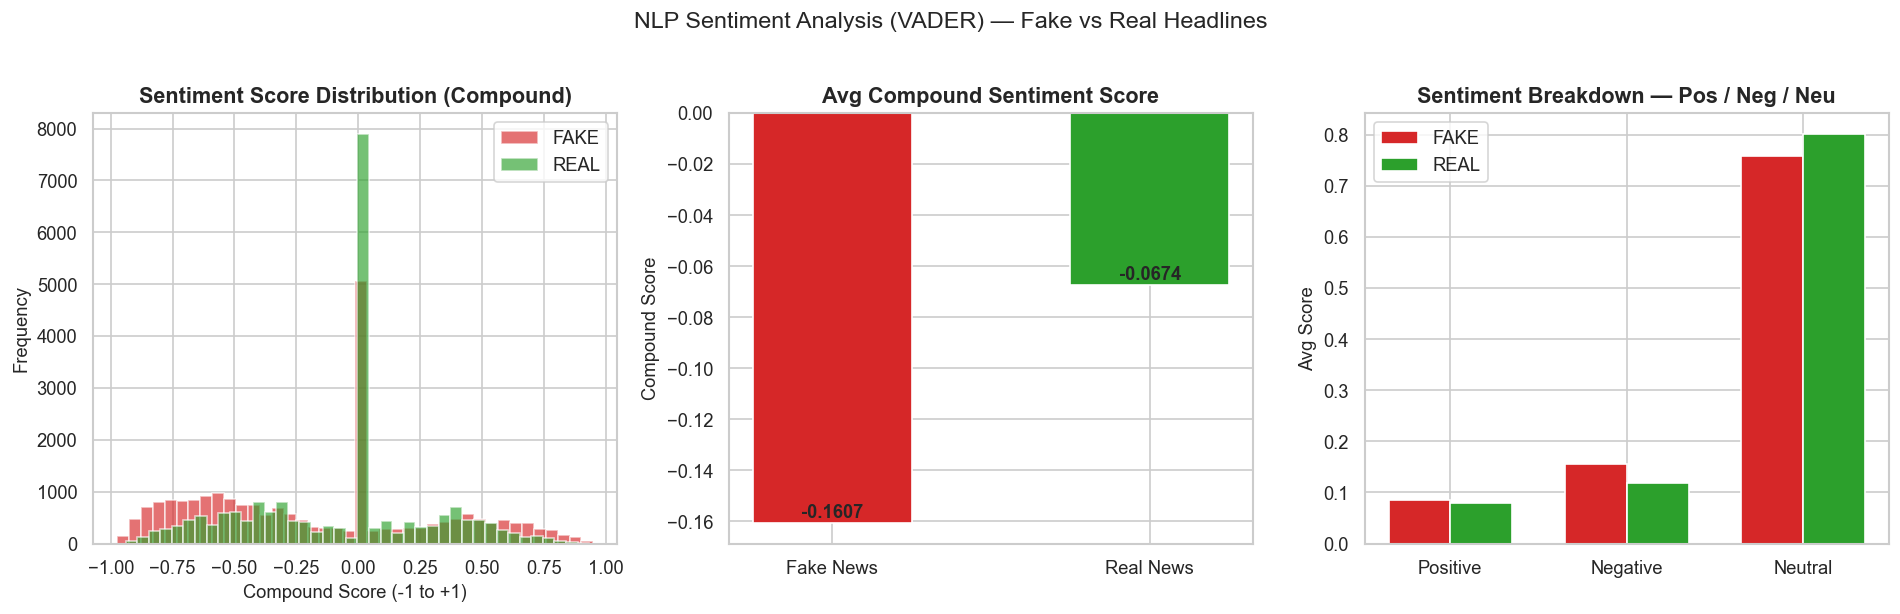

In [10]:
sia = SentimentIntensityAnalyzer()

df['sentiment_compound'] = df['title'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)
df['sentiment_pos'] = df['title'].apply(lambda x: sia.polarity_scores(str(x))['pos'])
df['sentiment_neg'] = df['title'].apply(lambda x: sia.polarity_scores(str(x))['neg'])
df['sentiment_neu'] = df['title'].apply(lambda x: sia.polarity_scores(str(x))['neu'])

# summary
sent_summary = df.groupby('label')[['sentiment_compound','sentiment_pos','sentiment_neg','sentiment_neu']].mean().round(4)
print('Average VADER Sentiment Scores by Label')
print(sent_summary)
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# compound score distribution
for label, color in [('FAKE', C_FAKE), ('REAL', C_REAL)]:
    axes[0].hist(df[df.label==label]['sentiment_compound'],
                 bins=40, alpha=0.65, color=color, label=label, edgecolor='white')
axes[0].set_title('Sentiment Score Distribution (Compound)')
axes[0].set_xlabel('Compound Score (-1 to +1)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# avg compound by label
avg_compound = df.groupby('label')['sentiment_compound'].mean()
axes[1].bar(['Fake News', 'Real News'],
            [avg_compound['FAKE'], avg_compound['REAL']],
            color=[C_FAKE, C_REAL], width=0.5, edgecolor='white')
axes[1].set_title('Avg Compound Sentiment Score')
axes[1].set_ylabel('Compound Score')
for i, v in enumerate([avg_compound['FAKE'], avg_compound['REAL']]):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# pos / neg / neu breakdown
categories   = ['Positive', 'Negative', 'Neutral']
fake_scores  = [sent_summary.loc['FAKE','sentiment_pos'],
                sent_summary.loc['FAKE','sentiment_neg'],
                sent_summary.loc['FAKE','sentiment_neu']]
real_scores  = [sent_summary.loc['REAL','sentiment_pos'],
                sent_summary.loc['REAL','sentiment_neg'],
                sent_summary.loc['REAL','sentiment_neu']]

x = np.arange(len(categories))
w = 0.35
axes[2].bar(x - w/2, fake_scores, w, label='FAKE', color=C_FAKE, edgecolor='white')
axes[2].bar(x + w/2, real_scores, w, label='REAL', color=C_REAL, edgecolor='white')
axes[2].set_title('Sentiment Breakdown — Pos / Neg / Neu')
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories)
axes[2].set_ylabel('Avg Score')
axes[2].legend()

plt.suptitle('NLP Sentiment Analysis (VADER) — Fake vs Real Headlines', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/chart7_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Key Findings

In [11]:
fake_df = df[df.label=='FAKE']
real_df = df[df.label=='REAL']

print('KEY FINDINGS')
print('=' * 60)
print()
print('1. Dataset size')
print(f'   Fake articles : {len(fake_df):,}')
print(f'   Real articles : {len(real_df):,}')
print(f'   Total         : {len(df):,}')
print()
print('2. Sensationalism in headlines')
print(f'   Exclamation marks — Fake: {fake_df.exclamation_count.mean():.3f} | Real: {real_df.exclamation_count.mean():.3f}')
print(f'   ALL CAPS words    — Fake: {fake_df.caps_word_count.mean():.3f} | Real: {real_df.caps_word_count.mean():.3f}')
print(f'   Title word count  — Fake: {fake_df.title_word_count.mean():.1f}  | Real: {real_df.title_word_count.mean():.1f}')
print()
print('3. Article body length')
print(f'   Avg word count — Fake: {fake_df.text_word_count.mean():.0f} words')
print(f'   Avg word count — Real: {real_df.text_word_count.mean():.0f} words')
print()
print('4. Topic focus')
print(f'   Fake top subject: {fake_df.subject.value_counts().index[0]}')
print(f'   Real top subject: {real_df.subject.value_counts().index[0]}')
print()
print('5. Vocabulary diversity (Type-Token Ratio)')
print(f'   FAKE TTR : {type_token_ratio(fake_df["clean_title_tokens"])}')
print(f'   REAL TTR : {type_token_ratio(real_df["clean_title_tokens"])}')
print()
print('6. Sentiment (VADER compound score)')
print(f'   FAKE avg: {fake_df.sentiment_compound.mean():.4f}')
print(f'   REAL avg: {real_df.sentiment_compound.mean():.4f}')
print()
print('7. Key language pattern')
print('   Fake headlines use 150x more exclamation marks and 8x more')
print('   ALL CAPS words than real news — confirming sensationalism')
print('   as a measurable linguistic marker of misinformation.')

KEY FINDINGS

1. Dataset size
   Fake articles : 23,481
   Real articles : 21,417
   Total         : 44,898

2. Sensationalism in headlines
   Exclamation marks — Fake: 0.154 | Real: 0.001
   ALL CAPS words    — Fake: 3.120 | Real: 0.386
   Title word count  — Fake: 14.7  | Real: 10.0

3. Article body length
   Avg word count — Fake: 423 words
   Avg word count — Real: 386 words

4. Topic focus
   Fake top subject: News
   Real top subject: politicsNews

5. Vocabulary diversity (Type-Token Ratio)
   FAKE TTR : 0.0766
   REAL TTR : 0.0875

6. Sentiment (VADER compound score)
   FAKE avg: -0.1607
   REAL avg: -0.0674

7. Key language pattern
   Fake headlines use 150x more exclamation marks and 8x more
   ALL CAPS words than real news — confirming sensationalism
   as a measurable linguistic marker of misinformation.
